 # Basic Charts

 This example shows how to draw certain charts using *roboquant*.
 It uses the `YahooFeed` to fetch historical data for several assets and then runs a
 simple EMA Crossover strategy. The results are visualized using the `matplotlib` library
 and the *roboquant* plotting capabilities.

In [ ]:
import roboquant as rq
import matplotlib.pyplot as plt

 Configure matplotlib with some defaults

In [ ]:
rq.set_light_style()
bg_color = "#F8FFF8"
plt.rcParams["figure.facecolor"] = bg_color
plt.rcParams["axes.facecolor"] = bg_color
plt.rcParams["savefig.facecolor"] = bg_color

 We create a feedwith with also some ETF's mixed in to get a more diversified mix of assets

In [ ]:
feed = rq.feeds.YahooFeed("MSFT", "F", "GLD", "GSG", "BND", "LQD", "IBIT", "VIXY")

 Plot a price chart for one of the assets in the feed

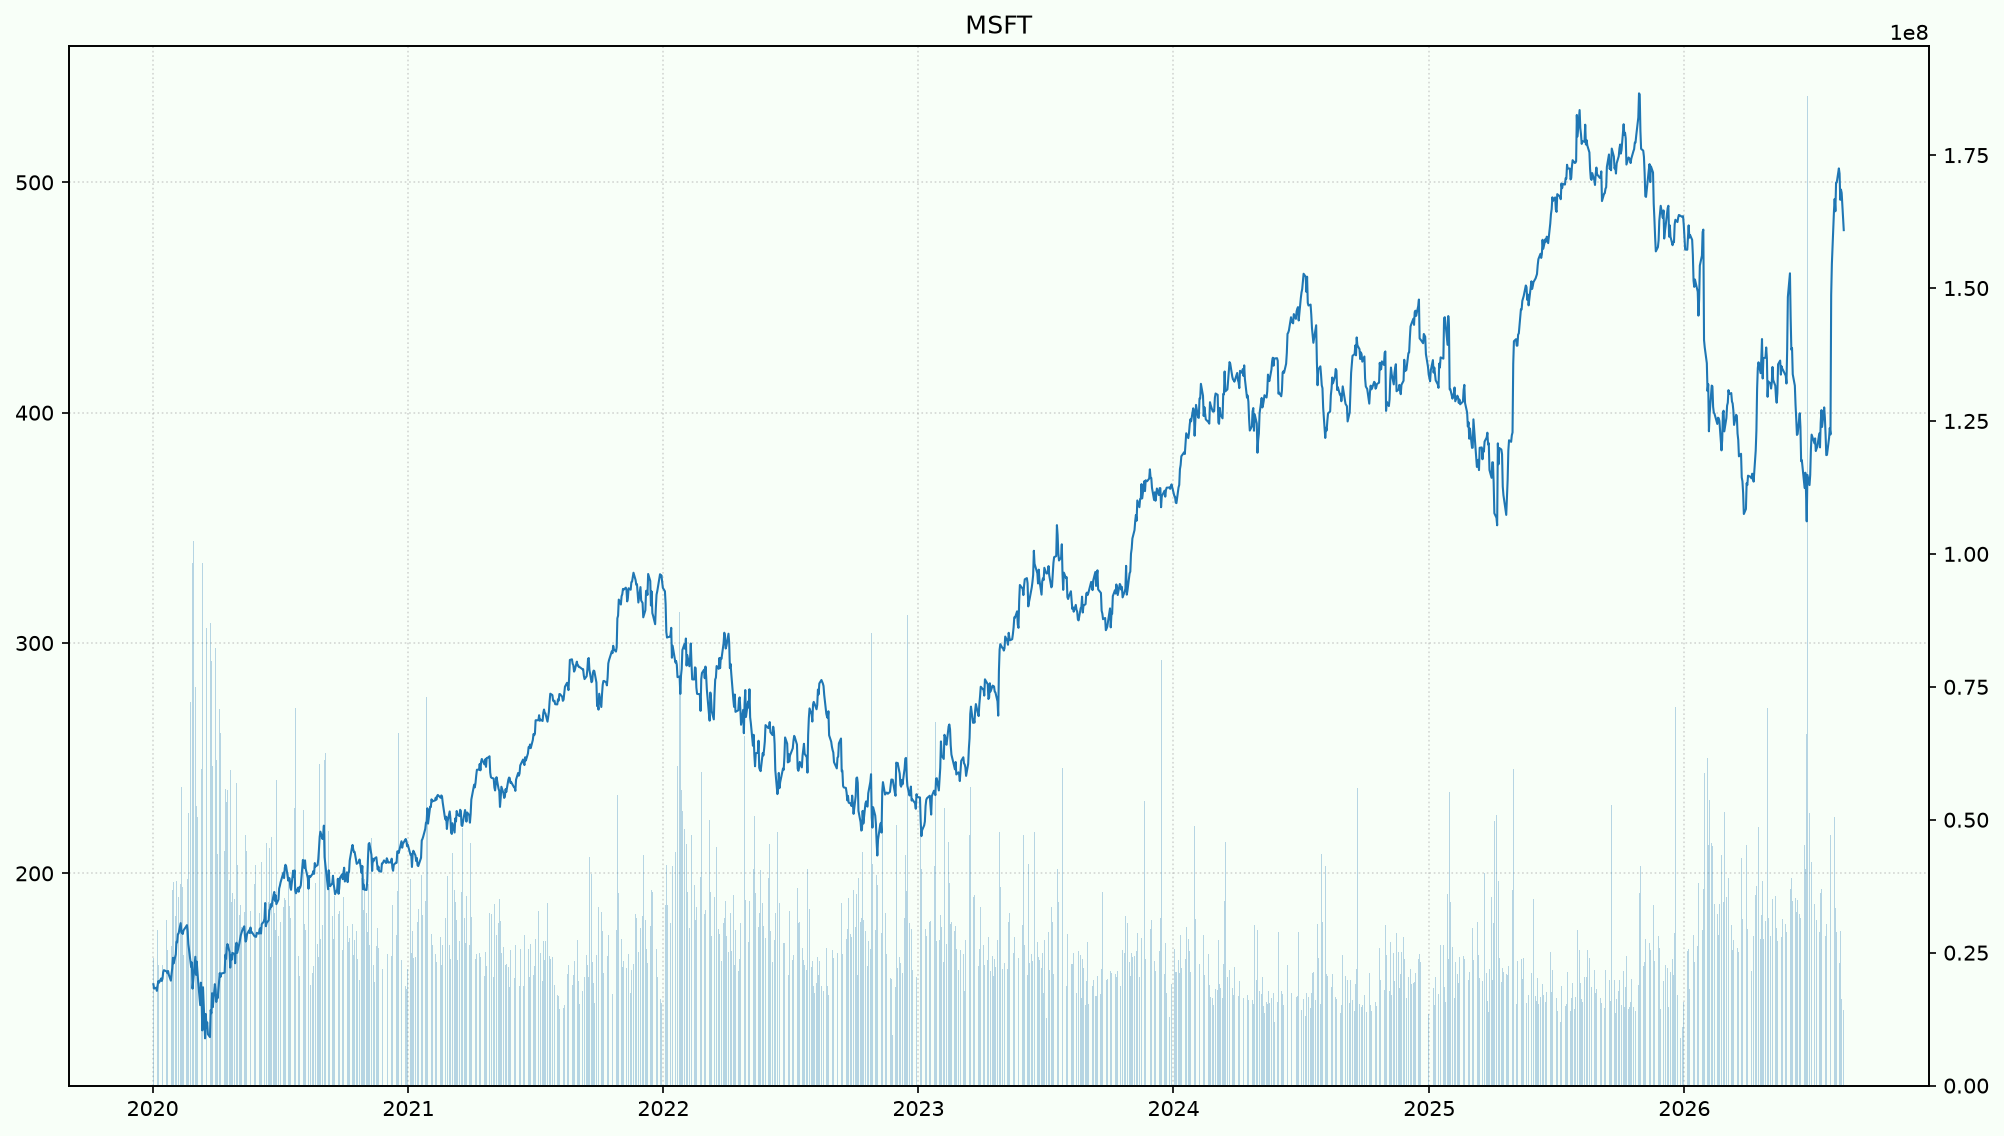

In [ ]:
feed.plot("MSFT");

In [ ]:
strategy = rq.strategies.EMACrossover()
journal = rq.journals.MetricsJournal.pnl()
account = rq.run(feed, strategy, journal=journal)
print(account)

buying power : 802,028@USD
cash         : 802,028@USD
equity       : 1,306,232@USD
positions    : 5113@GSG, 356@MSFT, 404@GLD
trades       : 373
mkt value    : 504,205@USD
orders       : none
last update  : 2026-08-17 04:00:00+00:00


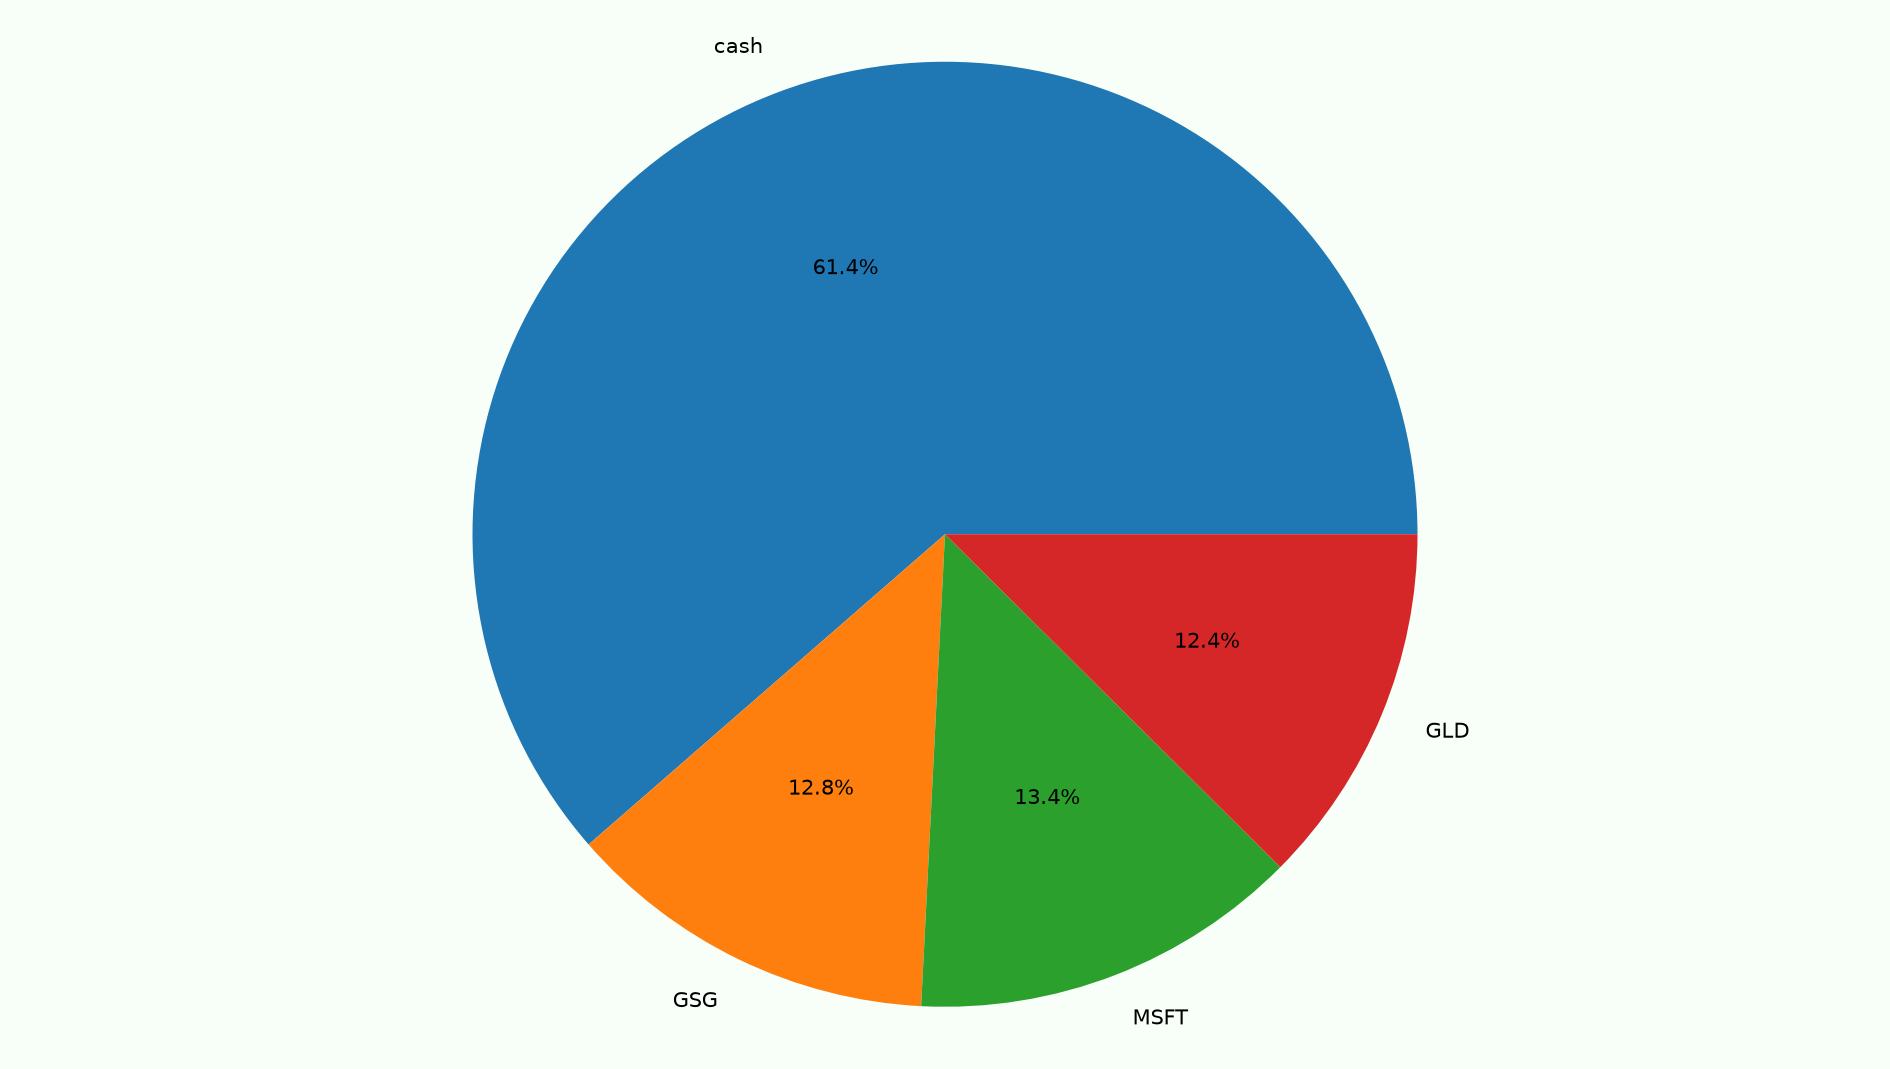

In [ ]:
account.plot_allocation(include_cash=True);

 ## Customize
 You can customize many of the plots by providing parameter arguments that will be passed on
 to matplotlib.

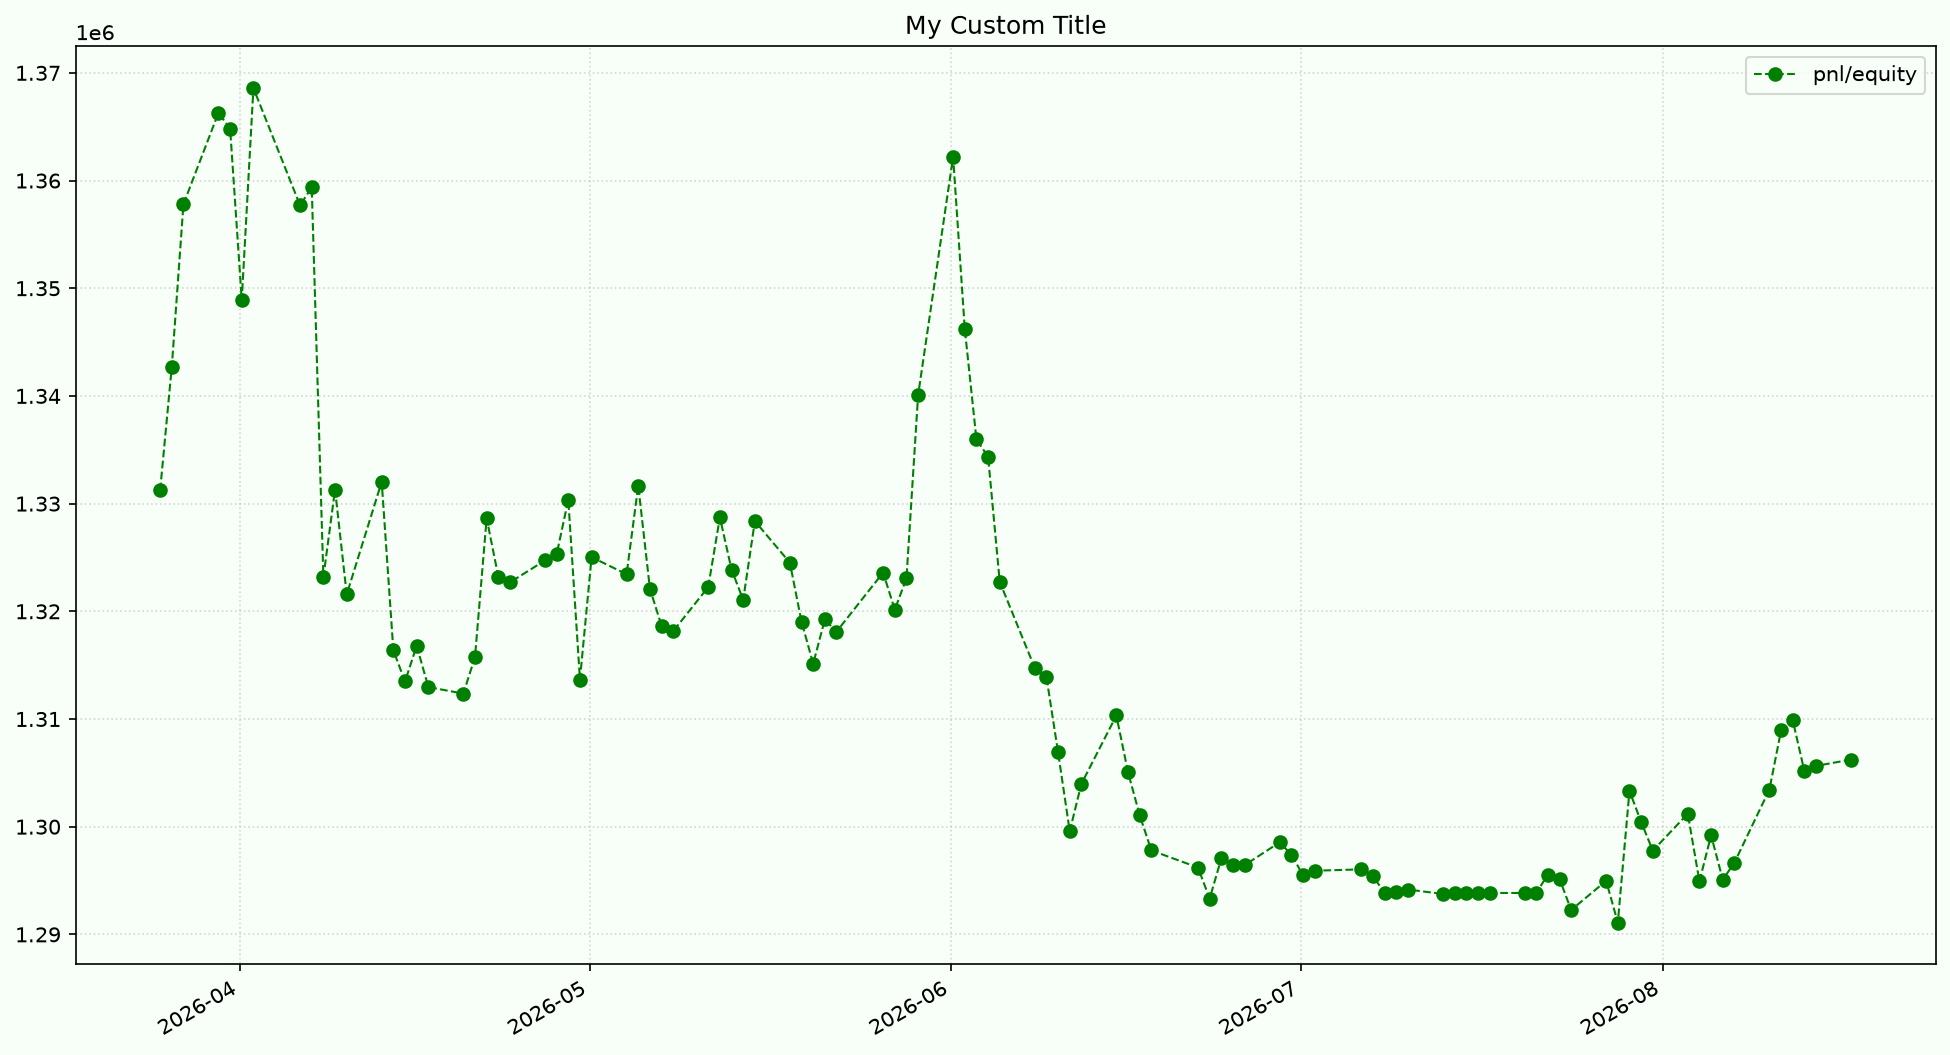

In [ ]:
equity = journal.get_metrics("pnl/equity")[-100:]
ax = equity.plot(color="green", linestyle="--", marker='o')
ax.set_title("My Custom Title");

 Or you can take full control of the figure and axes and create more
 advanced chart figures.

 Below we plot the equity curve and its 20-day rolling standard-deviation

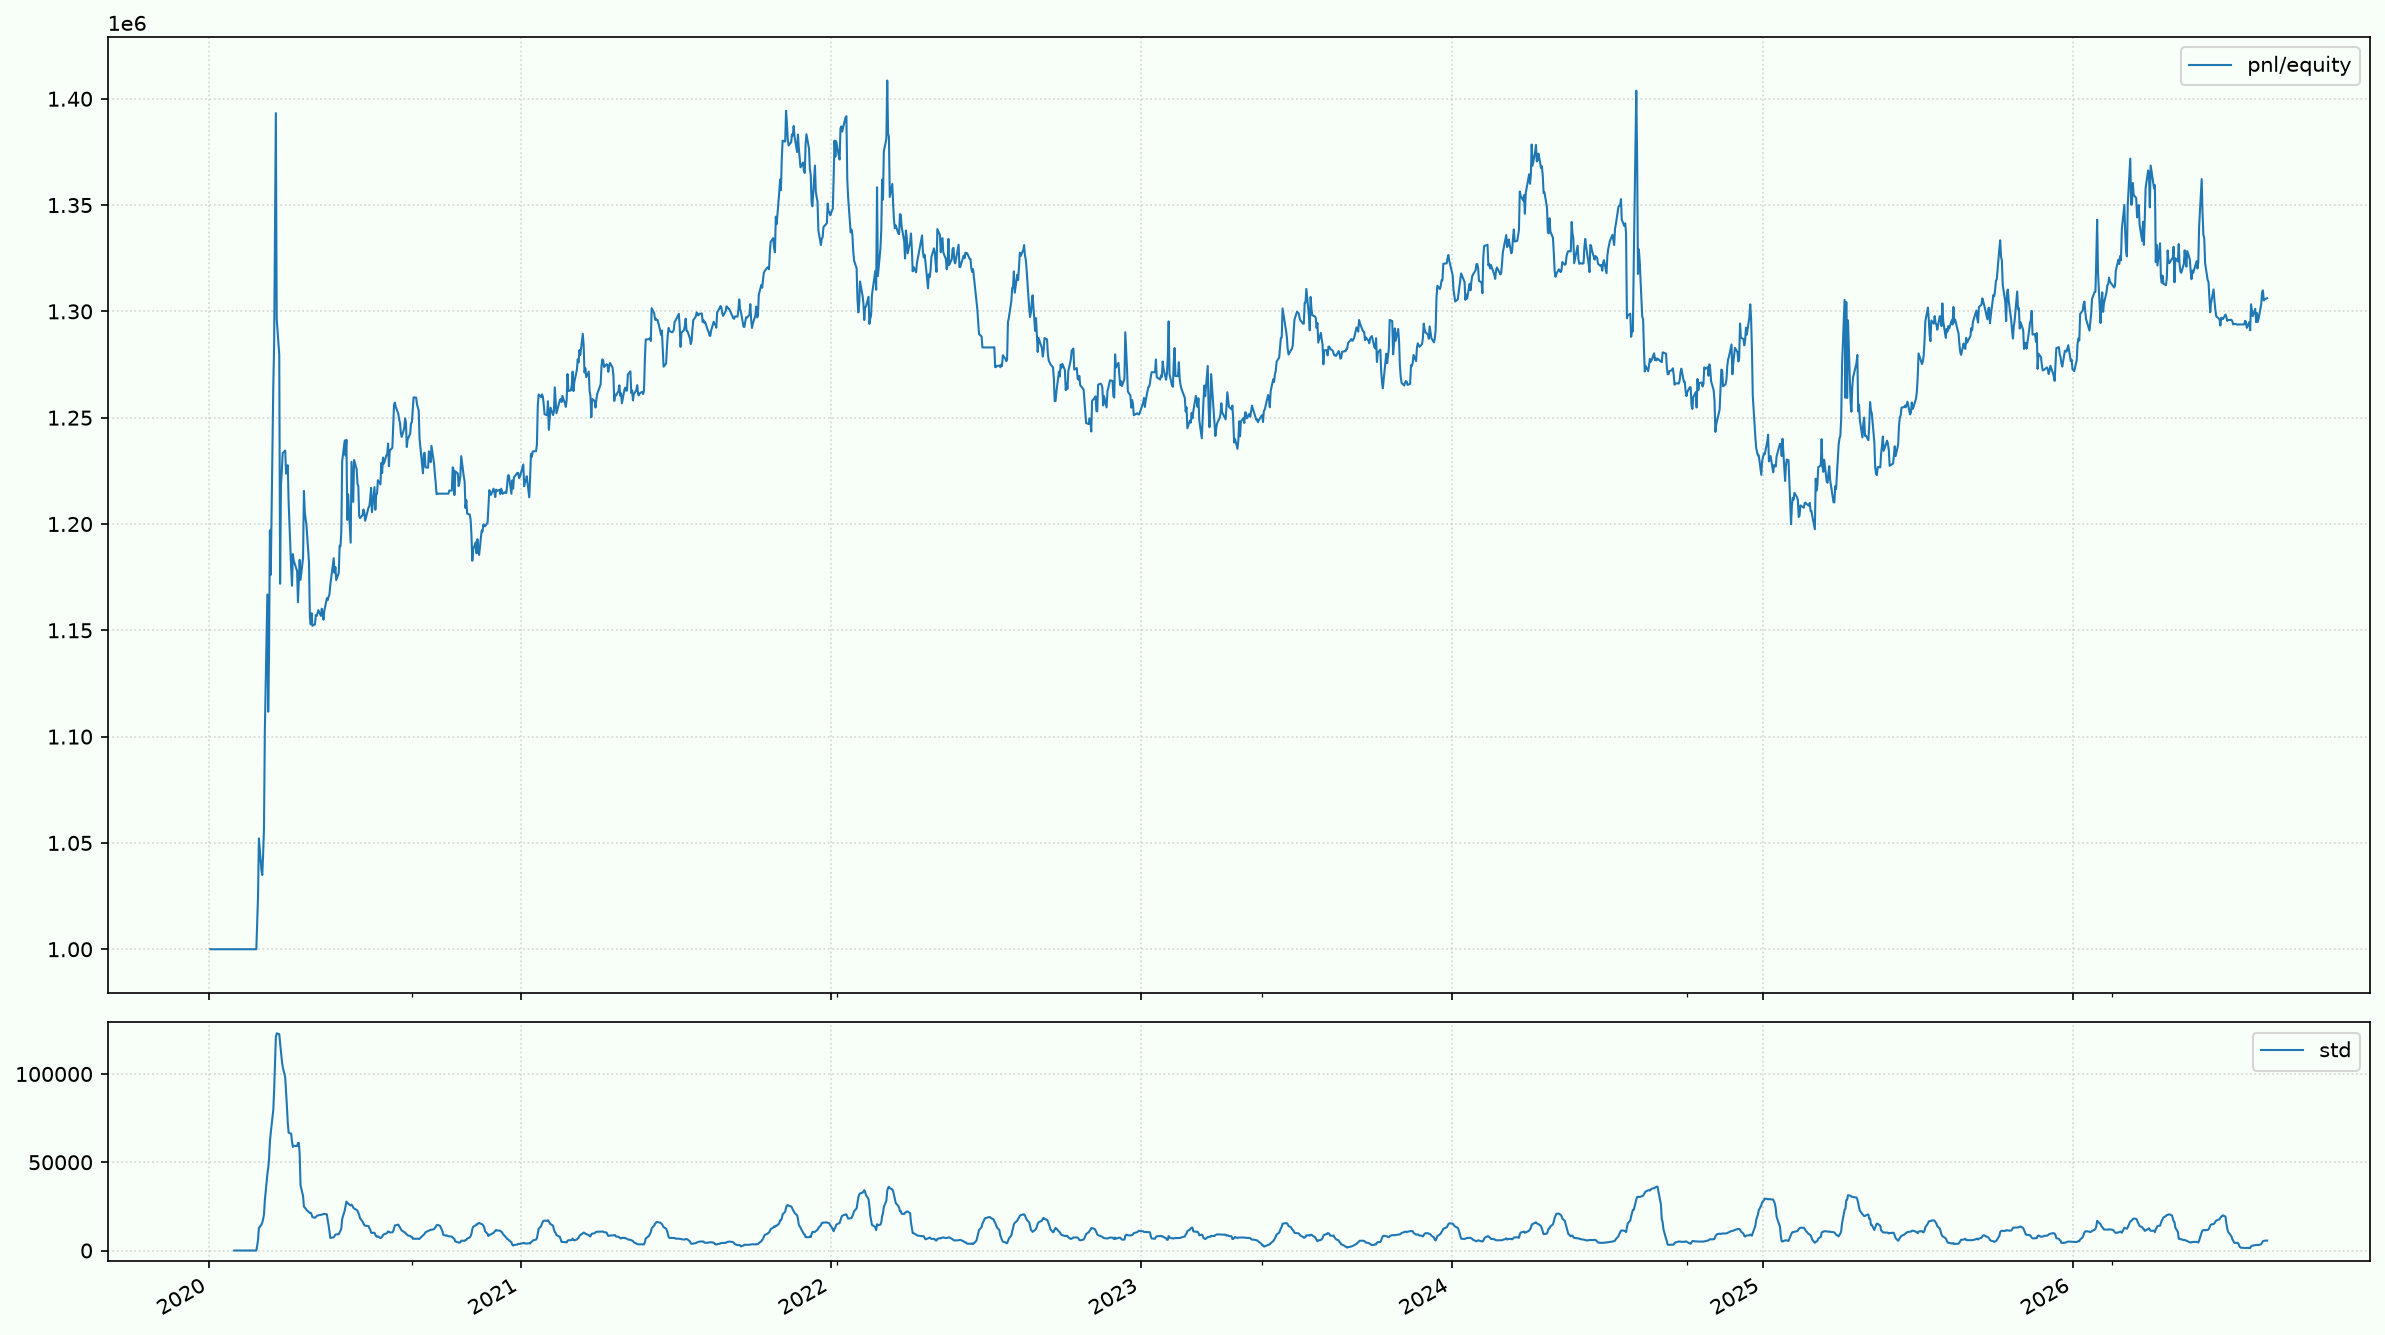

In [ ]:
fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True, height_ratios=[4,1])
equity = journal.get_metrics("pnl/equity")
equity.plot(ax=ax1)
equity_std = equity["pnl/equity"].rolling(20).std()
equity_std.plot(ax=ax2, label="std", legend=True)
fig.tight_layout();

 Below we create a figure with 8 subplots with a more infomative title.

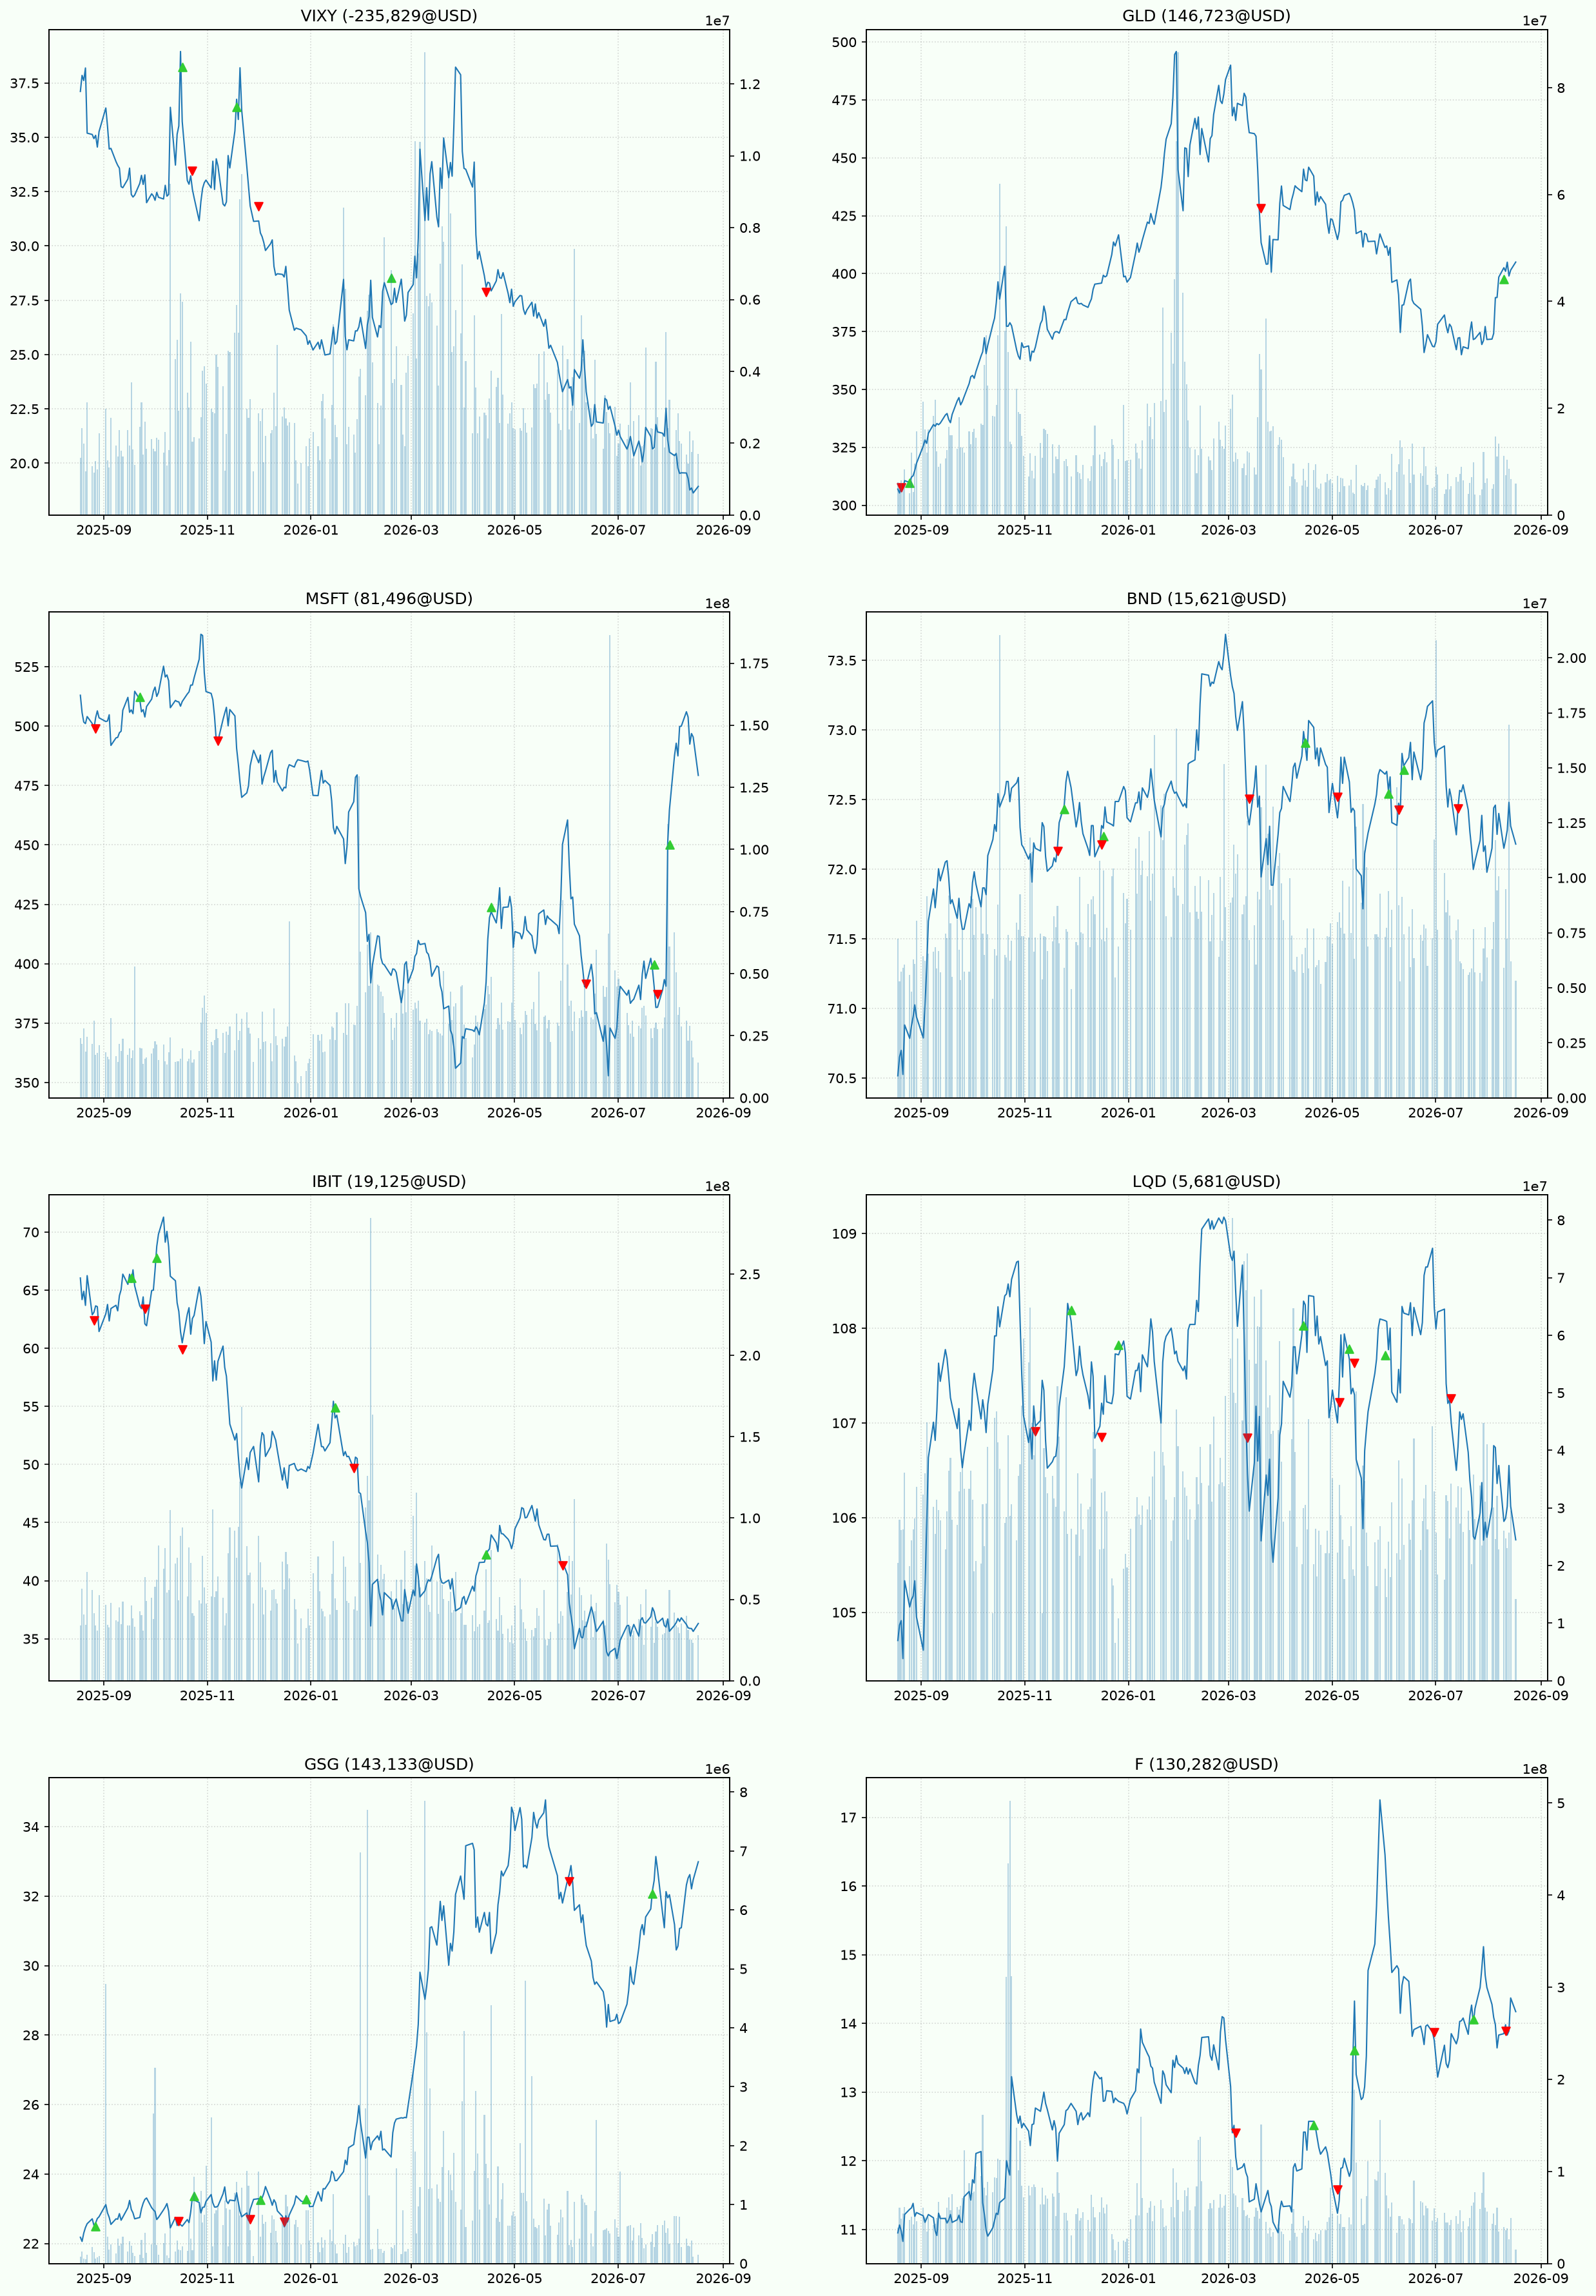

In [ ]:
tf = rq.Timeframe.previous("365 days")
_, axs = plt.subplots(4, 2, figsize=(20, 30))

for ax, asset in zip(axs.flatten(), feed.assets()):
    pnl = account.pnl(asset)
    ax = feed.plot(asset, timeframe=tf, ax=ax, trades=account.trades)
    ax.set_title(f"{asset.symbol} ({pnl:,.0f})")

 ## Multi-run
 Perform a walk forward over 4 equal timeframes and
 - plot each run on the same chart.

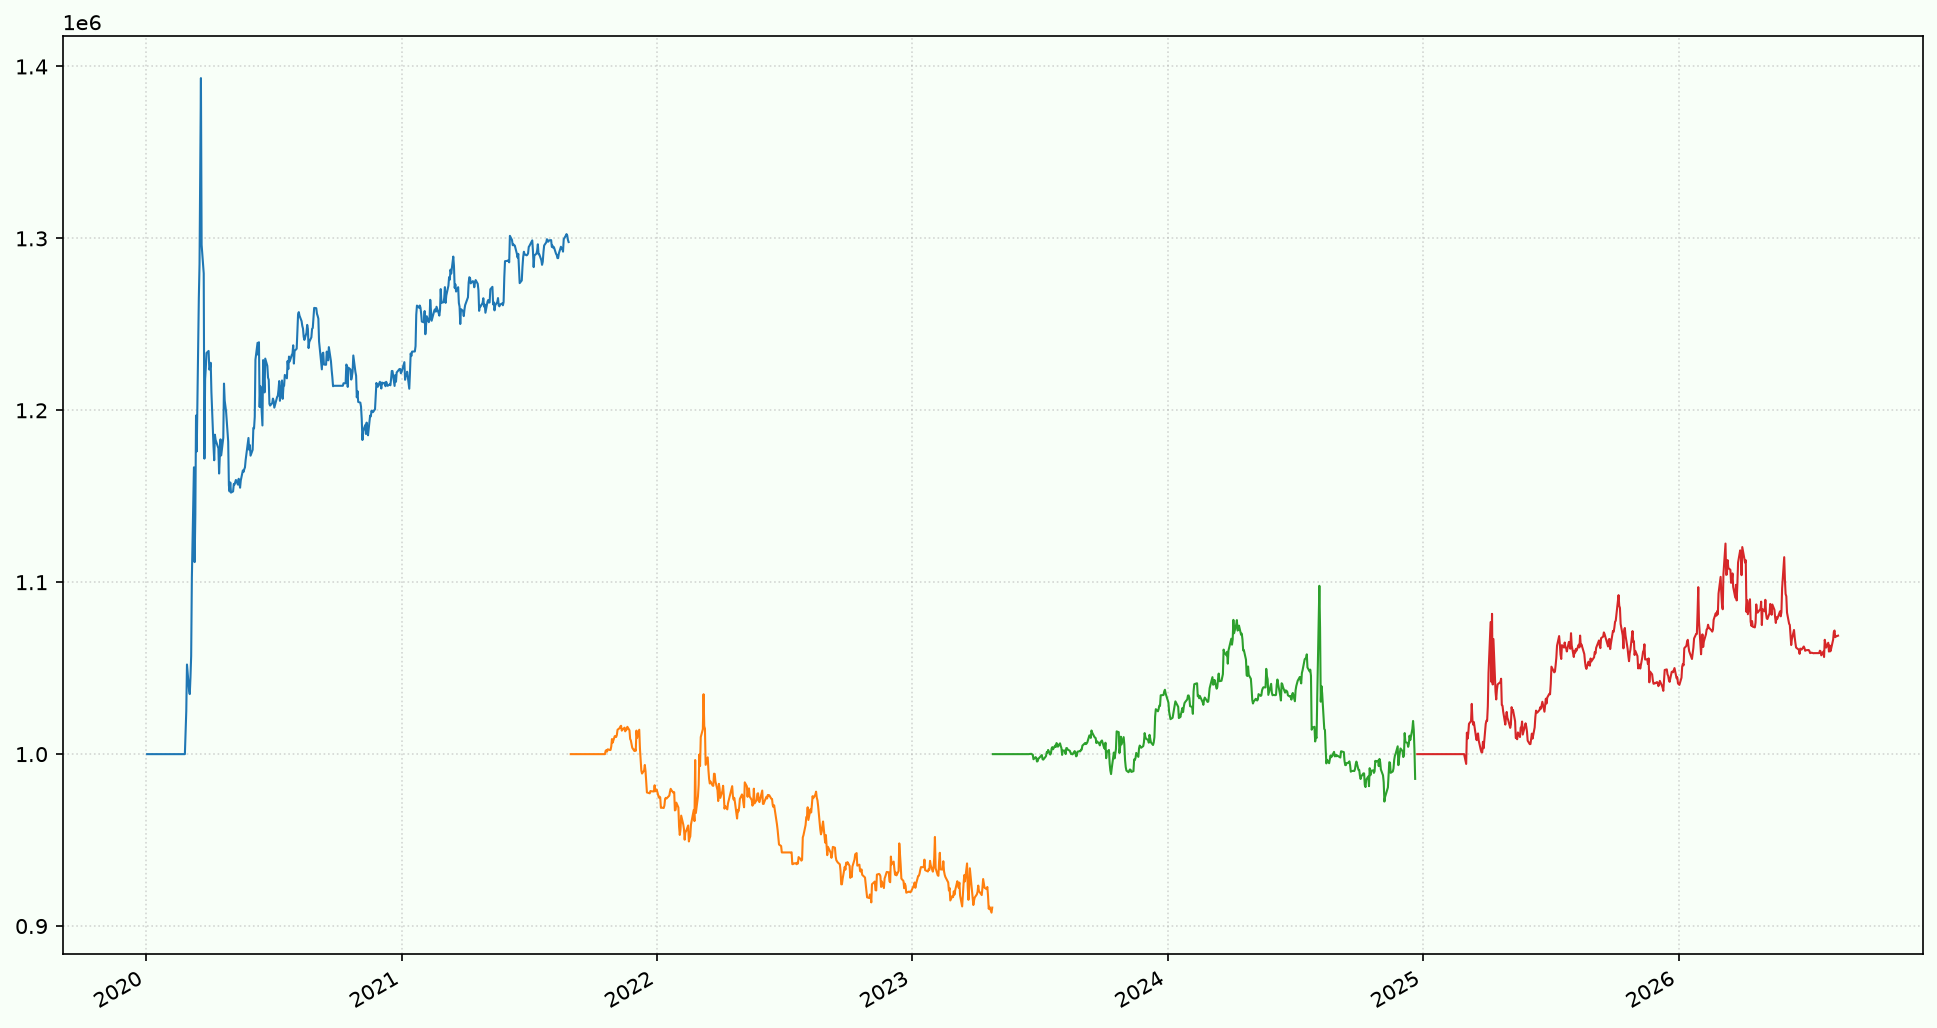

In [ ]:
timeframes = feed.timeframe().split(4)
ax = None

for timeframe in timeframes:
    strategy = rq.strategies.EMACrossover()
    journal = rq.journals.MetricsJournal.pnl()
    rq.run(feed, strategy, journal=journal, timeframe=timeframe)
    equity = journal.get_metrics("pnl/equity")
    ax = equity.plot(ax=ax, legend=False)

 Run randomly sampled 1-year back tests and plot the equity curve
 for each run on the same chart. This provides visual insights
 how the equity curves are distributed.

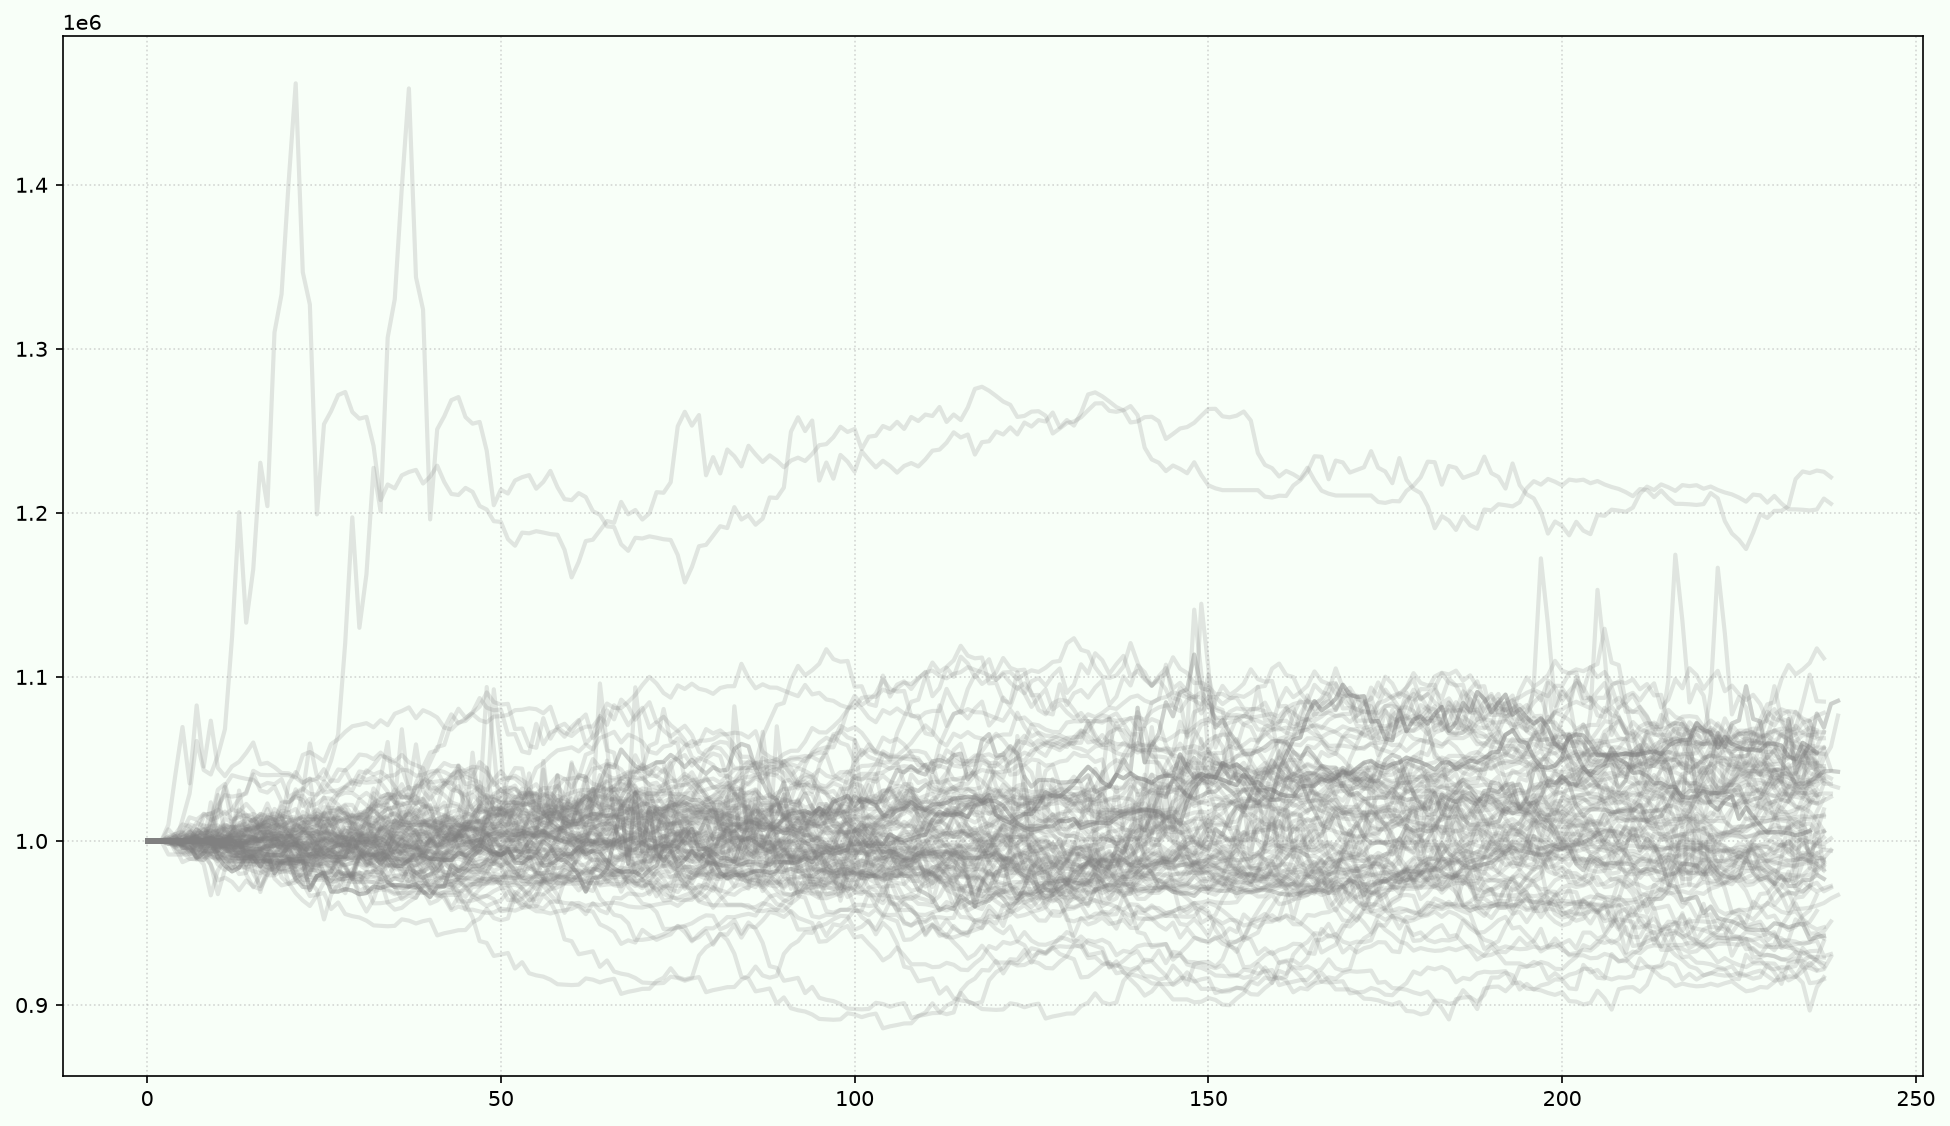

In [ ]:
timeframes = feed.timeframe().sample(100, "365 days")
ax = None

for timeframe in timeframes:
    strategy = rq.strategies.EMACrossover(5, 13)
    journal = rq.journals.MetricsJournal.pnl()
    rq.run(feed, strategy, journal=journal, timeframe=timeframe)

    # Skip the first 13 trading days since the strategy is still
    # warming up and the equity curve is flat during this period.
    equity = journal.get_metrics("pnl/equity")[13:]
    ax = equity.plot_without_timeline(ax=ax, linewidth=2, color="grey", alpha=0.2, legend=False)

 ## Correlation
 Sometimes it is useful to inspect the correlation between assets.
 There is a special plot that makes this visibe.

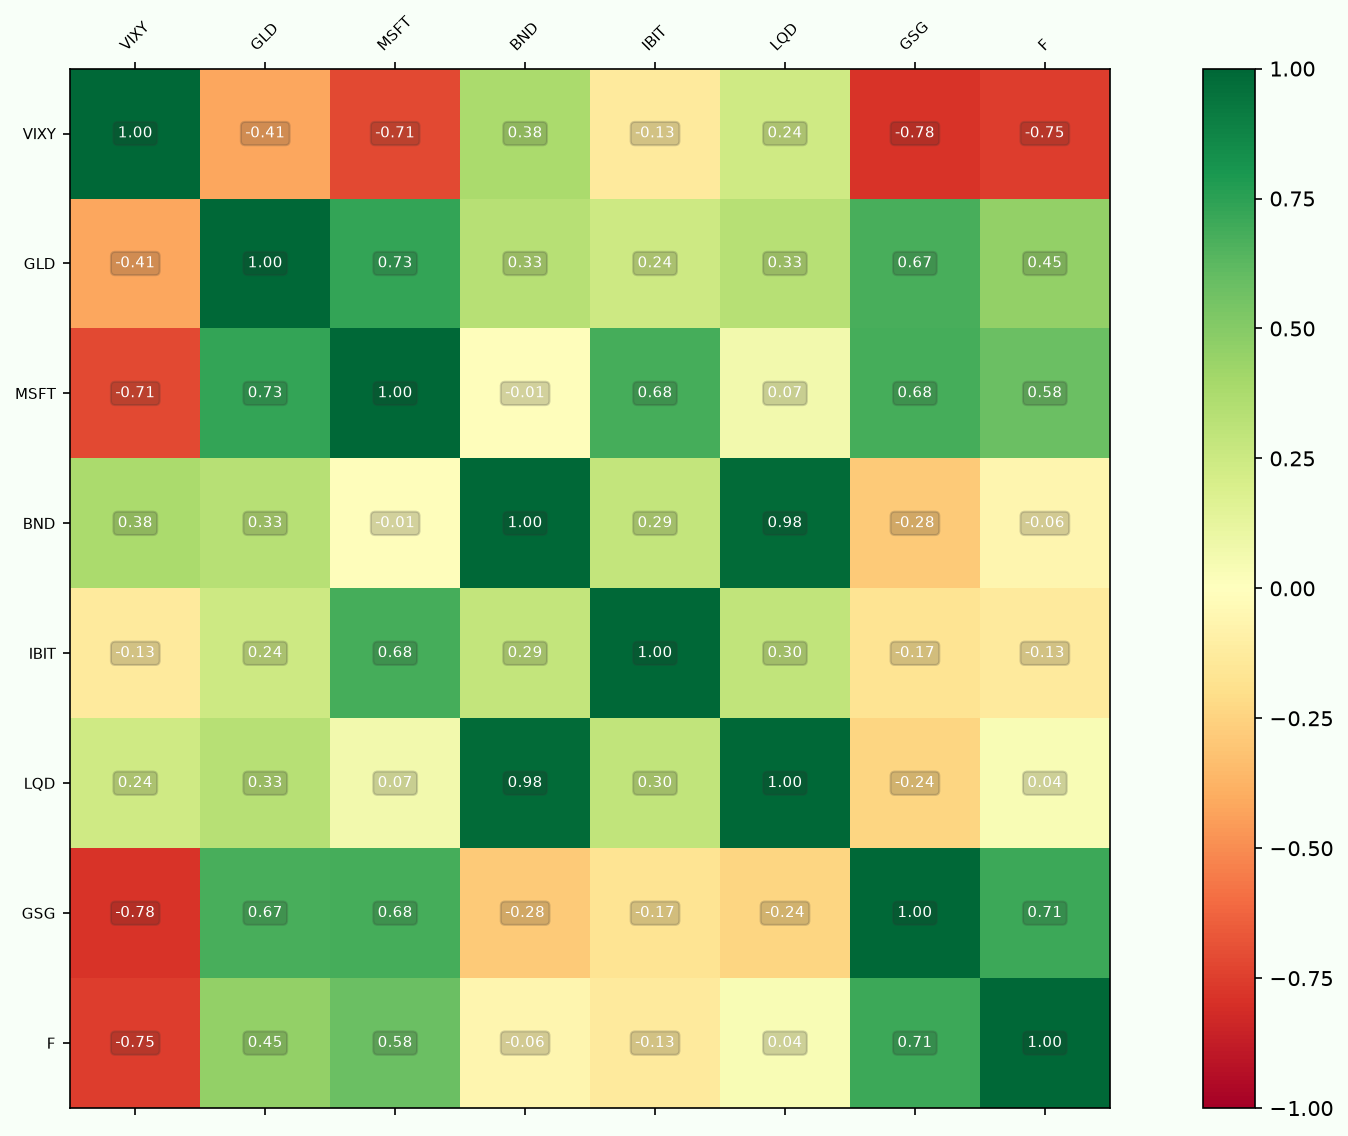

In [ ]:
feed.to_timeseries().plot_corr(fontsize=7);